### Autor: Agnieszka Grala
Zadania:

$\begin{array}{ccc}
1&2&3&4&5&6&7\\
X&X&X&X&X&X&X
\end{array}$

## Assignment 1

**Submission deadlines:**
- get at least **2** points by Tuesday, 11.03.2025
- remaining points: last lab session before or on Tuesday, 18.03.2025

**Points:** Aim to get 8 out of 14 possible points

## Submission instructions
The class is held on-site in lab rooms. Please prepare you notebook on your computer or anywhere in the cloud (try using DeepNote or Google Colab).

Make sure you know all the questions and answers, and that the notebook contains results; before presentation do `Runtime -> Restart and run all`
![Picture title](image-20220302-183151.png)

We provide starter code, however you are not required to use it as long as you properly solve the tasks.


# Task description

## TLDR
Implement and train a neural network using pure `torch`.


## Problem 1 [2p]
Implement a two-layer network, manually set weights and biases to solve the XOR task.

A two-layer neural network implementes a function $f: \mathbb{R}^D \rightarrow \mathbb{R}^O$ where $D$ is the input dimensionality and $O$ is the output dinemsionality. The output goes through an intermediate representation (the hidden layer) with dimensionality $H$.

The computations are as follows:
$$
\begin{aligned}
A_1 &= x W_1^T + b_1  & \qquad\text{Total input to neurons in the hidden layer (network's first layer)} \\
O_1 &= \sigma_1(A_1)  & \qquad\text{Output of the hidden layer} \\
A_2 &= O_1 W_2^T + b_2 & \qquad\text{Total input to neurons in the output layer (network's second layer)}\\
O_2 &= \sigma_2(A_2)  & \qquad\text{Output of the network}
\end{aligned}
$$

Where $W$ are weight matrices, $b$ are bias vectors, $\sigma$ are non-linear activation functions (e.g. the logistic sigmoid applied element-wise, or softmax).

For the 2D xor problem the network will:
- have 2 inputs, 2 hidden neurons, one output
- use the logistic sigmoid everywhere (that way we, when hand-designig the weights, we can assume that neurons' outputs are binary).

Therrefore the shapes of the data flowing through the network will be:
- input: $x\in\mathbb{}R^{2}$
- hidden layer parameters: $W_1\in\mathbb{}R^{2\times 2}$ and $b_1\in\mathbb{}R^{2}$
- representations in the hidden layer: $A_1\in\mathbb{}R^{2}$ and $O_1\in\mathbb{}R^{2}$
- output layer parameters: $W_2\in\mathbb{}R^{1\times 2}$ and $b_2\in\mathbb{}R^{1}$
- representations in the output layer: $A_2\in\mathbb{}R^{1}$ and $O_2\in\mathbb{}R^{1}$

The network can be seen as a logistic regression model, prefixed by a nonlinear transformation of the data.

The first tasks consists of:
- implementing the network
- selecting parametwrs ($W_1, b_1, W_2, b_2$) such that $f(x)\approx XOR(x_1, x_2)$ where the approximation is die to the sigmoids - the output may be close to 0 or 1, but doesn't need to saturate at 0 or 1.

NB: the convention on weight matrix shapes follows linear [layers in PyTorch](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html).


## Problem 2 [2p]
1. Add a backward pass.
2. Use a sensible random initialization for weights and biases.
3. Numerically check the correctness of your gradient computation.

There is nice article about taking derivative over vectors and vector chain rule: https://explained.ai/matrix-calculus/ if someone don't have experience with such calculus.


## Problem 3 [2p]
1. Implement gradient descent
2. Train your network to solve 3D XOR
3. Try several hidden layer sizes, for each size record the fracton of successful trainings. Then answer:
    - What is the minimal hidden size required to solve 3D XOR (even with low reliability, when the training has to be repeated multiple times)
    - What is the minimal hidden size required to reliably solve 3D XOR
    - Which networks are easier to train - small or large ones? Why?


## Problem 4 [1p]
Replace the first nonlinearity with the [ReLU](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)) activation function. Find a network architecture which reliably learns the 3D XOR problem.


## Problem 5 [1p]
Add a second hidden layer to your network, implement the forward and backward pass, then demonstrate training.


## Problem 6 [2p]
Implement a way to have a _variable number_ of hidden layers. Check how deep sigmoid or ReLU networks you  can train. For simplicity you can assume that all hidden layers have the same number of neurons, and use the same activation function.


## Problem 7 [2p]
Consider the following function $\boldsymbol f: \mathbb R^n \to \mathbb R^k$:
$$ \hat{\boldsymbol y} := \boldsymbol f(\boldsymbol x\,;\,\,W, \boldsymbol b) = \mathrm{softmax}(\boldsymbol z) \qquad (\boldsymbol x \in \mathbb R^{n}, \, W \in\mathbb R^{k\times n}, \, \boldsymbol b \in \mathbb R^k), $$
where $$ \boldsymbol z = W  \boldsymbol x + \boldsymbol b $$
and $W, \boldsymbol b$ are the parameters.

Analytically derive the form of the following gradients:

$$ \frac{\partial \hat{\boldsymbol y}}{\boldsymbol z} = \ldots $$

$$ \frac{\partial \hat{\boldsymbol y}}{W_{ij}} = \ldots $$

$$ \frac{\partial \hat{\boldsymbol y}}{\boldsymbol b} = \ldots $$

# Solutions and starter code

In [ ]:
import matplotlib.pyplot as plt
import torch

XOR dataset creation

(-0.05, 1.05, -0.05, 1.05)

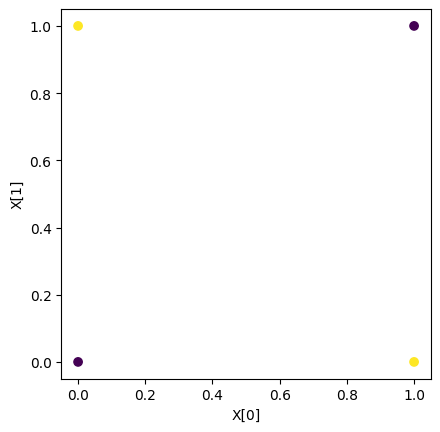

In [ ]:
# Let's define a XOR dataset

# X will be matrix of N 2-dimensional inputs
X = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1],], dtype=torch.float64)
# Y is a matrix of N numners - answers
Y = torch.tensor([[0], [1], [1], [0],], dtype=torch.float64)

plt.scatter(
    X[:, 0], X[:, 1], c=Y[:, 0],
)
plt.xlabel("X[0]")
plt.ylabel("X[1]")
plt.axis("square")

## Problem 1

The code below contains a mock-up of a two-layer neural network. Fill in the code and manually set weights to solve the XOR problem.

Please note: the shapes are set to be compatible with PyTorch's conventions:
* a batch containing $N$ $D$-dimensional examples has shape $N\times D$ (each example is a row!)
* a weight matrix in a linear layer with $I$ inputs and $O$ outputs has shape $O \times I$
* a bias vector is a 1D vector. Please note that [broadcasting rules](https://docs.scipy.org/doc/numpy/user/basics.broadcasting.html) allow us to think about it as a $1 \times D$ matrix.

In [ ]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))


class SmallNet:
    def __init__(self, in_features: int, num_hidden: int, dtype=torch.float32):
        self.W1 = torch.zeros((num_hidden, in_features), dtype=dtype)
        self.b1 = torch.zeros((num_hidden,), dtype=dtype)
        self.W2 = torch.zeros((1, num_hidden), dtype=dtype)
        self.b2 = torch.zeros((1,), dtype=dtype)
        self.init_params(in_features, num_hidden)

    def init_params(self, in_features, num_hidden):
        # TODO for Problem 2:
        # set all parameters to small random values, e.g. from N(0, 0.5)
        self.W1 = torch.randn((num_hidden, in_features), dtype=torch.float64) * 0.5
        self.b1 = torch.randn((num_hidden,), dtype=torch.float64) * 0.5
        self.W2 = torch.randn((1, num_hidden), dtype=torch.float64) * 0.5
        self.b2 = torch.randn((1,), dtype=torch.float64) * 0.5

    def forward(self, X, Y=None, do_backward=False, first_activation=sigmoid):
        # TODO Problem 1: Fill in details of forward propagation

        # Input to neurons in 1st layer
        A1 = X @ self.W1.T + self.b1
        # Outputs after the sigmoid non-linearity
        O1 = first_activation(A1)
        # Inputs to neuron in the second layer
        A2 = O1 @ self.W2.T + self.b2
        # Outputs after the sigmoid non-linearity
        O2 = sigmoid(A2)

        # When Y is none, simply return the predictions. Else compute the loss
        if Y is not None:
            loss = -(Y * torch.log(O2) + (1 - Y) * torch.log(1 - O2))
            # normalize loss by batch size
            loss = loss.sum() / X.shape[0]
        else:
            loss = torch.nan

        if do_backward:
            # TODO in Problem 2:
            # fill in the gradient computation
            # Please note, that there is a correspondance between
            # the forward and backward pass: with backward computations happening
            # in reverse order.
            # We save the gradients with respect to the parameters as fields of self.
            # It is not very elegant, but simplifies training code later on.

            # A2_grad is the gradient of loss with respect to A2
            # Hint: there is a concise formula for the gradient
            # of logistic sigmoid and cross-entropy loss
            A2_grad = (O2 - Y) / X.shape[0]  # dloss/dA2 = dloss/dO2 * dO2/dA2
            self.b2_grad = A2_grad.sum(0)
            self.W2_grad = A2_grad.T @ O1
            O1_grad = A2_grad @ self.W2
            if first_activation == sigmoid:
              A1_grad = O1_grad * O1 * (1 - O1)
            elif first_activation == relu:
              A1_grad = O1_grad * torch.where(A1 > 0, torch.tensor(1.0), torch.tensor(0.0))
            self.b1_grad = A1_grad.sum(0)
            self.W1_grad = A1_grad.T @ X

        return O2, loss

In [ ]:
# TODO Problem 1:
# Set the weight values to solve the XOR problem

net = SmallNet(2, 2, dtype=torch.float64)
net.W1 = torch.tensor([[10., 10.], [-10., -10.]], dtype=torch.float64)
net.b1 = torch.tensor([-5., 15.], dtype=torch.float64)
net.W2 = torch.tensor([[10., 10.]], dtype=torch.float64)
net.b2 = torch.tensor([-15.], dtype=torch.float64)

# Hint: since we use the logistic sigmoid activation, the weights may need to
# be fairly large

predictions, loss = net.forward(X, Y, do_backward=True)
for x, p in zip(X, predictions):
    print(f"XORnet({x}) = {p[0]}")

XORnet(tensor([0., 0.], dtype=torch.float64)) = 0.007152788188896484
XORnet(tensor([0., 1.], dtype=torch.float64)) = 0.9923558641717396
XORnet(tensor([1., 0.], dtype=torch.float64)) = 0.9923558641717396
XORnet(tensor([1., 1.], dtype=torch.float64)) = 0.007152788188896484


## Problem 2

In [ ]:
def check_grad(net, param_name, X, Y, eps=1e-5):
    """A gradient checking routine"""

    param = getattr(net, param_name)
    param_flat_accessor = param.reshape(-1)

    grad = torch.empty_like(param)
    grad_flat_accessor = grad.reshape(-1)

    net.forward(X, Y, do_backward=True)
    orig_grad = getattr(net, param_name + "_grad")
    assert param.shape == orig_grad.shape

    for i in range(param_flat_accessor.shape[0]):
        orig_val = param_flat_accessor[i].item()
        param_flat_accessor[i] = orig_val + eps
        _, loss_positive = net.forward(X, Y)
        param_flat_accessor[i] = orig_val - eps
        _, loss_negative = net.forward(X, Y)
        param_flat_accessor[i] = orig_val
        grad_flat_accessor[i] = (loss_positive - loss_negative) / (2 * eps)
    assert torch.allclose(grad, orig_grad)
    return grad, orig_grad

In [ ]:
# Hint: use float64 for checking the correctness of the gradient
net = SmallNet(2, 2, dtype=torch.float64)

for param_name in ["W1", "b1", "W2", "b2"]:
    check_grad(net, param_name, X, Y)

## Problem 3

In [ ]:
net = SmallNet(2, 10, dtype=torch.float64)

def gradient_descent(net, X, Y, alpha, verbose=True, first_activation=sigmoid):
  for i in range(100000):
      res, loss = net.forward(X, Y, do_backward=True, first_activation=first_activation)
      if (i % 5000) == 0 and verbose:
          print(f"after {i} steps \tloss={loss}")
      for param_name in ["W1", "b1", "W2", "b2"]:
          param = getattr(net, param_name)
          # Hint: use the construct `param[:]` to change the contents of the array!
          # Doing instead `param = new_val` simply changes to what the variable
          # param points to, without affecting the network!
          # alternatively, you could do setattr(net, param_name, new_value)
          param[:] = param - alpha * getattr(net, param_name + "_grad")
  return res, loss

_ = gradient_descent(net, X, Y, 0.1)

after 0 steps 	loss=0.8822186605213175
after 5000 steps 	loss=0.13512475819639247
after 10000 steps 	loss=0.014368494081347848
after 15000 steps 	loss=0.006725855802706095
after 20000 steps 	loss=0.004284248914351202
after 25000 steps 	loss=0.0031115510934145866
after 30000 steps 	loss=0.0024297288245836426
after 35000 steps 	loss=0.001986425512056889
after 40000 steps 	loss=0.0016762040875727734
after 45000 steps 	loss=0.0014475004003323749
after 50000 steps 	loss=0.0012722122996666595
after 55000 steps 	loss=0.0011337587839130912
after 60000 steps 	loss=0.0010217431106408232
after 65000 steps 	loss=0.0009293246883086625
after 70000 steps 	loss=0.0008518233007349437
after 75000 steps 	loss=0.000785931434933199
after 80000 steps 	loss=0.0007292470402973566
after 85000 steps 	loss=0.0006799845423336565
after 90000 steps 	loss=0.0006367896447208013
after 95000 steps 	loss=0.0005986169596197121


In [ ]:
predictions, loss = net.forward(X, Y, do_backward=True)
for x, p in zip(X, predictions):
    print(f"XORnet({x}) = {p[0]}")

XORnet(tensor([0., 0.], dtype=torch.float64)) = 0.0005497840842584315
XORnet(tensor([0., 1.], dtype=torch.float64)) = 0.9995168149406047
XORnet(tensor([1., 0.], dtype=torch.float64)) = 0.9993990026435126
XORnet(tensor([1., 1.], dtype=torch.float64)) = 0.0006239780001029372


In [ ]:
# TODO:
# Generate data for a 3D XOR task
# Then estimate the success rate of training the network with diferent
# hidden sizes.
import itertools

X3 = torch.tensor(list(itertools.product([0, 1], repeat=3)), dtype=torch.float64)
Y3 = (X3.sum(dim=1) % 2).view(-1, 1)

for hidden_dim in [2, 3, 5, 10, 20]:
    # TODO: run a few trainings and record the fraction of successful ones
    print(f"hidden_dim = {hidden_dim}")
    successful_trainings = 0
    for _ in range(10):
      net = SmallNet(3, hidden_dim, dtype=torch.float64)
      res, loss = gradient_descent(net, X3, Y3, 0.1, verbose=False)
      predictions = (res >= 0.5).float()
      if torch.equal(predictions, Y3):
        successful_trainings += 1
    print(f"Fraction of successful trainings: {successful_trainings / 10}")

hidden_dim = 2
Fraction of successful trainings: 0.2
hidden_dim = 3
Fraction of successful trainings: 1.0
hidden_dim = 5
Fraction of successful trainings: 1.0
hidden_dim = 10
Fraction of successful trainings: 1.0
hidden_dim = 20
Fraction of successful trainings: 1.0


    - What is the minimal hidden size required to solve 3D XOR (even with low reliability, when the training has to be repeated multiple times)
    Minimal hidden size required to solve 3D XOR is 2.
    - What is the minimal hidden size required to reliably solve 3D XOR
    To reliably solve 3D XOR (to solve it every time) we need hidden size >= 3.
    - Which networks are easier to train - small or large ones? Why?
    Large networks are easier to train due to larger number of parameters. They can catch more complex patterns and don't compress information that much during training, making training more stable.

## Problem 4


In [ ]:
def relu(x):
  return torch.maximum(torch.tensor(0.0), x)

for hidden_dim in range(2, 11):
    # TODO: run a few trainings and record the fraction of successful ones
    print(f"hidden_dim = {hidden_dim}")
    successful_trainings = 0
    for _ in range(10):
      net = SmallNet(3, hidden_dim, dtype=torch.float64)
      res, loss = gradient_descent(net, X3, Y3, 0.1, verbose=False, first_activation=relu)
      predictions = (res >= 0.5).float()
      if torch.equal(predictions, Y3):
        successful_trainings += 1
    print(f"Fraction of successful trainings: {successful_trainings / 10}")

hidden_dim = 2
Fraction of successful trainings: 0.0
hidden_dim = 3
Fraction of successful trainings: 0.2
hidden_dim = 4
Fraction of successful trainings: 0.4
hidden_dim = 5
Fraction of successful trainings: 0.4
hidden_dim = 6
Fraction of successful trainings: 0.7
hidden_dim = 7
Fraction of successful trainings: 0.8
hidden_dim = 8
Fraction of successful trainings: 0.9
hidden_dim = 9
Fraction of successful trainings: 0.9
hidden_dim = 10
Fraction of successful trainings: 0.8


## Problem 5

In [ ]:
class TwoLayerNet:
    def __init__(self, in_features: int, first_num_hidden: int, second_num_hidden: int, dtype=torch.float32):
        self.W1 = torch.zeros((first_num_hidden, in_features), dtype=dtype)
        self.b1 = torch.zeros((first_num_hidden,), dtype=dtype)
        self.W2 = torch.zeros((second_num_hidden, first_num_hidden), dtype=dtype)
        self.b2 = torch.zeros((second_num_hidden,), dtype=dtype)
        self.W3 = torch.zeros((1, second_num_hidden), dtype=dtype)
        self.b3 = torch.zeros((1,), dtype=dtype)
        self.init_params(in_features, first_num_hidden, second_num_hidden)

    def init_params(self, in_features, first_num_hidden, second_num_hidden):
        self.W1 = torch.randn((first_num_hidden, in_features), dtype=torch.float64) * 0.5
        self.b1 = torch.randn((first_num_hidden,), dtype=torch.float64) * 0.5
        self.W2 = torch.randn((second_num_hidden, first_num_hidden), dtype=torch.float64) * 0.5
        self.b2 = torch.randn((second_num_hidden,), dtype=torch.float64) * 0.5
        self.W3 = torch.randn((1, second_num_hidden), dtype=torch.float64) * 0.5
        self.b3 = torch.randn((1,), dtype=torch.float64) * 0.5

    def forward(self, X, Y=None, do_backward=False, first_activation=sigmoid):
        # Input to neurons in 1st layer
        A1 = X @ self.W1.T + self.b1
        # Outputs after the sigmoid non-linearity
        O1 = first_activation(A1)
        # Inputs to neuron in the second layer
        A2 = O1 @ self.W2.T + self.b2
        # Outputs after the sigmoid non-linearity
        O2 = sigmoid(A2)
        # Input to neurons in third layer
        A3 = O2 @ self.W3.T + self.b3
        # Outputs after the sigmoid non-linearity
        O3 = sigmoid(A3)

        # When Y is none, simply return the predictions. Else compute the loss
        if Y is not None:
            loss = -(Y * torch.log(O3) + (1 - Y) * torch.log(1 - O3))
            # normalize loss by batch size
            loss = loss.sum() / X.shape[0]
        else:
            loss = torch.nan

        if do_backward:
            A3_grad = (O3 - Y) / X.shape[0]
            self.b3_grad = A3_grad.sum(0)
            self.W3_grad = A3_grad.T @ O2
            O2_grad = A3_grad @ self.W3
            A2_grad = O2_grad * O2 * (1 - O2)
            self.b2_grad = A2_grad.sum(0)
            self.W2_grad = A2_grad.T @ O1
            O1_grad = A2_grad @ self.W2
            if first_activation == sigmoid:
              A1_grad = O1_grad * O1 * (1 - O1)
            elif first_activation == relu:
              A1_grad = O1_grad * torch.where(A1 > 0, torch.tensor(1.0), torch.tensor(0.0))
            self.b1_grad = A1_grad.sum(0)
            self.W1_grad = A1_grad.T @ X

        return O3, loss

In [ ]:
def gradient_descent_two_layers(net, X, Y, alpha, verbose=True, first_activation=sigmoid):
  for i in range(100000):
      res, loss = net.forward(X, Y, do_backward=True, first_activation=first_activation)
      if (i % 5000) == 0 and verbose:
          print(f"after {i} steps \tloss={loss}")
      for param_name in ["W1", "b1", "W2", "b2", "W3", "b3"]:
          param = getattr(net, param_name)
          # Hint: use the construct `param[:]` to change the contents of the array!
          # Doing instead `param = new_val` simply changes to what the variable
          # param points to, without affecting the network!
          # alternatively, you could do setattr(net, param_name, new_value)
          param[:] = param - alpha * getattr(net, param_name + "_grad")
  return res, loss

In [ ]:
net = TwoLayerNet(3, 3, 3, dtype=torch.float64)
_ = gradient_descent_two_layers(net, X3, Y3, 0.1)

after 0 steps 	loss=0.7228852373779919
after 5000 steps 	loss=0.6931492884339688
after 10000 steps 	loss=0.6931479197439072
after 15000 steps 	loss=0.6931465855572716
after 20000 steps 	loss=0.6931451262076174
after 25000 steps 	loss=0.6931433548185186
after 30000 steps 	loss=0.6931410066255852
after 35000 steps 	loss=0.6931376486121342
after 40000 steps 	loss=0.693132484472121
after 45000 steps 	loss=0.6931238666919312
after 50000 steps 	loss=0.6931078596152965
after 55000 steps 	loss=0.6930729570522871
after 60000 steps 	loss=0.6929726264005214
after 65000 steps 	loss=0.6924480387527157
after 70000 steps 	loss=0.6689267998783481
after 75000 steps 	loss=0.039403548653193246
after 80000 steps 	loss=0.006477838805069907
after 85000 steps 	loss=0.0029076731432651627
after 90000 steps 	loss=0.0017828145384130225
after 95000 steps 	loss=0.0012600463835484364


## Problem 6

In [ ]:
def sigmoid_derivative(output):
    return output * (1 - output)

def relu_derivative(output):
    return (output > 0).float()

class MultiLayerNet:
    def __init__(self, in_features: int, hidden_dim: int, hidden_layers_num: int, dtype=torch.float64, activation="sigmoid"):
        self.hidden_layers_num = hidden_layers_num
        self.hidden_dim = hidden_dim
        self.in_features = in_features
        self.out_features = 1
        self.Ws = []
        self.bs = []
        self.Ws_grad = []
        self.bs_grad = []
        self.init_params(dtype)
        if activation.lower() == "relu":
            self.activation = relu
            self.activation_deriv = relu_derivative
        else:
            self.activation = sigmoid
            self.activation_deriv = sigmoid_derivative

    def init_params(self, dtype):
      W0 = torch.randn((self.hidden_dim, self.in_features), dtype=dtype) * 0.5
      b0 = torch.randn((self.hidden_dim,), dtype=dtype) * 0.5
      self.Ws.append(W0)
      self.bs.append(b0)

      for _ in range(self.hidden_layers_num - 1):
          W = torch.randn((self.hidden_dim, self.hidden_dim), dtype=dtype) * 0.5
          b = torch.randn((self.hidden_dim,), dtype=dtype) * 0.5
          self.Ws.append(W)
          self.bs.append(b)

      W_out = torch.randn((1, self.hidden_dim), dtype=dtype) * 0.5
      b_out = torch.randn((1,), dtype=dtype) * 0.5
      self.Ws.append(W_out)
      self.bs.append(b_out)

      self.Ws_grad = [torch.zeros_like(W) for W in self.Ws]
      self.bs_grad = [torch.zeros_like(b) for b in self.bs]


    def forward(self, X, Y=None, do_backward=False):
        A = []
        O = []

        current_input = X

        for i in range(self.hidden_layers_num):
            Wi = self.Ws[i]
            bi = self.bs[i]

            Ai = current_input @ Wi.T + bi
            A.append(Ai)

            Oi = self.activation(Ai)
            O.append(Oi)
            current_input = Oi

        out_idx = self.hidden_layers_num
        W_out = self.Ws[out_idx]
        b_out = self.bs[out_idx]

        A_out = current_input @ W_out.T + b_out
        A.append(A_out)
        O_out = sigmoid(A_out)
        O.append(O_out)

        if Y is not None:
            loss = -(Y * torch.log(O_out) + (1 - Y) * torch.log(1 - O_out))
            loss = loss.mean()
        else:
            loss = torch.nan

        if do_backward and Y is not None:
            N = X.shape[0]
            dA_out = (O_out - Y) / N

            self.Ws_grad[out_idx] = dA_out.T @ O[out_idx - 1] if self.hidden_layers_num > 0 else dA_out.T @ X
            self.bs_grad[out_idx] = dA_out.sum(dim=0)

            dO_prev = dA_out @ self.Ws[out_idx]

            for i in reversed(range(self.hidden_layers_num)):
                dA_i = dO_prev * self.activation_deriv(O[i])

                if i == 0:
                    X_input = X
                else:
                    X_input = O[i - 1]

                self.Ws_grad[i] = dA_i.T @ X_input
                self.bs_grad[i] = dA_i.sum(dim=0)

                dO_prev = dA_i @ self.Ws[i]

        return O_out, loss

In [ ]:
def gradient_descent_multilayer(net, X, Y, alpha=0.1, max_steps=100000, verbose=True):
    for i in range(max_steps):
        O, loss = net.forward(X, Y, do_backward=True)

        for idx in range(len(net.Ws)):
            net.Ws[idx] = net.Ws[idx] - alpha * net.Ws_grad[idx]
            net.bs[idx] = net.bs[idx] - alpha * net.bs_grad[idx]

        if (i % (max_steps // 10)) == 0 and verbose:
            print(f"Step {i} / {max_steps} | loss = {loss.item():.6f}")

    return O, loss

In [ ]:
net = MultiLayerNet(3, 10, 4)
O, loss = gradient_descent_multilayer(net, X3, Y3)
print(f"Final loss: {loss}")

Step 0 / 100000 | loss = 0.890966
Step 10000 / 100000 | loss = 0.693142
Step 20000 / 100000 | loss = 0.693031
Step 30000 / 100000 | loss = 0.692267
Step 40000 / 100000 | loss = 0.005218
Step 50000 / 100000 | loss = 0.000546
Step 60000 / 100000 | loss = 0.000280
Step 70000 / 100000 | loss = 0.000187
Step 80000 / 100000 | loss = 0.000140
Step 90000 / 100000 | loss = 0.000112
Final loss: 9.336615334783168e-05


In [ ]:
def test_depths(X, Y, hidden_dims, depths, activation="sigmoid",
                max_steps=5000, lr=0.1, verbose=False):
    results = []
    for depth in depths:
        net = MultiLayerNet(
            in_features=X.shape[1],
            hidden_dim=hidden_dims,
            hidden_layers_num=depth,
            activation=activation
        )

        _, final_loss = gradient_descent_multilayer(
            net,
            X,
            Y,
            alpha=lr,
            max_steps=max_steps,
            verbose=verbose
        )

        results.append((depth, float(final_loss.detach())))
        print(f"{activation.upper()} Network - Hidden Layers: {depth} - Final Loss: {final_loss:.6f}")

    return results

In [ ]:
depths_to_test = [1, 2, 3, 4, 5, 6]

print("Testing Sigmoid Networks...")
sigmoid_results = test_depths(
    X3, Y3,
    hidden_dims=4,
    depths=depths_to_test,
    activation="sigmoid",
    max_steps=100000,
    lr=0.1
)

print("\nSigmoid results:", sigmoid_results)

print("\nTesting ReLU Networks...")
relu_results = test_depths(
    X3, Y3,
    hidden_dims=4,
    depths=depths_to_test,
    activation="relu",
    max_steps=100000,
    lr=0.1
)

print("\nReLU results:", relu_results)

Testing Sigmoid Networks...
SIGMOID Network - Hidden Layers: 1 - Final Loss: 0.000672
SIGMOID Network - Hidden Layers: 2 - Final Loss: 0.000284
SIGMOID Network - Hidden Layers: 3 - Final Loss: 0.000240
SIGMOID Network - Hidden Layers: 4 - Final Loss: 0.693093
SIGMOID Network - Hidden Layers: 5 - Final Loss: 0.693145
SIGMOID Network - Hidden Layers: 6 - Final Loss: 0.693147

Sigmoid results: [(1, 0.0006716669267373689), (2, 0.0002835028801339433), (3, 0.00024044534816580274), (4, 0.693093219110865), (5, 0.6931453911374073), (6, 0.6931471544072498)]

Testing ReLU Networks...
RELU Network - Hidden Layers: 1 - Final Loss: 0.351360
RELU Network - Hidden Layers: 2 - Final Loss: 0.000122
RELU Network - Hidden Layers: 3 - Final Loss: 0.000107
RELU Network - Hidden Layers: 4 - Final Loss: 0.693147
RELU Network - Hidden Layers: 5 - Final Loss: 0.693147
RELU Network - Hidden Layers: 6 - Final Loss: 0.173432

ReLU results: [(1, 0.35136041017883657), (2, 0.00012246794274663119), (3, 0.0001071419957

## Problem 7

### 1. $\frac{\partial \hat y}{\partial z}$ (the Jacobian of softmax w.r.t. z)

Since softmax is a $\mathbb R^n \rightarrow \mathbb R^n$ function, we need to compute the Jacobian matrix.

Each component of $\hat y$ is:

$$
\hat{y}_p(\mathbf{z}) = \frac{e^{z_p}}{\sum_{i=1}^k e^{z_i}}
$$

We need to calculate

$$
\frac{\partial \hat{y}_p}{\partial z_q} = \frac{\partial}{\partial z_q} \left( \frac{e^{z_p}}{\sum_{i=1}^k e^{z_i}} \right)
$$

If $p = q$ we have

$$
\frac{\partial \hat{y}_p}{\partial z_q} = \frac{\partial}{\partial z_q} \left( \frac{e^{z_p}}{\sum_{i=1}^k e^{z_i}} \right) = \frac{e^{z_p}\sum_{i=1}^k e^{z_i} - e^{2z_p}}{(\sum_{i=1}^k e^{z_i})^2} = \frac{e^{z_p}}{\sum_{i=1}^k e^{z_i}} \frac{\sum_{i=1}^k e^{z_i} - e^{z_p}}{\sum_{i=1}^k e^{z_i}} = \hat y_p (1 - \hat y_p)
$$

If $p \neq q$ we have

$$
\frac{\partial \hat{y}_p}{\partial z_q} = \frac{\partial}{\partial z_q} \left( \frac{e^{z_p}}{\sum_{i=1}^k e^{z_i}} \right) = \frac{- e^{z_p} e^{z_q}}{(\sum_{i=1}^k e^{z_i})^2} = -\frac{e^{z_p}}{\sum_{i=1}^k e^{z_i}} \frac{e^{z_q}}{\sum_{i=1}^k e^{z_i}} = -\hat y_p \hat y_q
$$

So, the diagonal entries of our Jacobian matrix are $\hat y_p (1 - \hat y_p)$ and the off-diagonal entries are $- \hat y_p \hat y_q$. We can now combine these results to get the matrix form of the gradient:

$$
\frac{\partial \hat y}{\partial z} = \mathrm{diag}(\hat{\mathbf{y}}) - \hat{\mathbf{y}} \hat{\mathbf{y}}^\top
$$

### 2. $\frac{\partial \hat y}{\partial W_{ij}}$

We can note that $\hat y$ depends on W only through z=Wx+b. Applying the chain rule:

$$
\frac{\partial \hat y_p}{\partial W_{ij}} = \sum^k_{q=1} \frac{\partial \hat y_p}{\partial z_q} \frac{\partial z_q}{\partial W_{ij}}
$$

Since
$$
z_q = \sum^n_{m=1} W_{qm} x_m + b_q
$$

If $q = i$ we have
$$
\frac{\partial z_q}{\partial W_{ij}} = x_j
$$

If $q \neq i$ we have
$$
\frac{\partial z_q}{\partial W_{ij}} = 0
$$

Therefore only the $q = i$ term survives the sum:
$$
\frac{\partial \hat y_p}{\partial W_{ij}} = \frac{\partial \hat y_p}{\partial z_i} x_j
$$

We already know $\frac{\partial \hat y_p}{\partial z_i}$, so we can write $\frac{\partial \hat y}{\partial W_{ij}}$ in matrix form:
$$
\frac{\partial \hat y}{\partial W_{ij}} = (\mathrm{diag}(\hat{\mathbf{y}}) - \hat{\mathbf{y}} \hat{\mathbf{y}}^\top) e_i x_j
$$
where $e_i$ is is the i-th standard basis vector in $\mathbb R^k$.

### 3. $\frac{\partial \hat y}{\partial b}$
Like in previous gradient, since z=Wx+b, we have:
$$
\frac{\partial \hat y_p}{\partial b_r} = \sum^k_{q=1} \frac{\partial \hat y_p}{\partial z_q} \frac{\partial z_q}{\partial b_r}
$$

If $q = r$:
$$
\frac{\partial z_q}{\partial b_r} = 1
$$

If $q \neq r$:
$$
\frac{\partial z_q}{\partial b_r} = 0
$$

This gives us:
$$
\frac{\partial \hat y_p}{\partial b_r} = \sum^k_{q=1} \frac{\partial \hat y_p}{\partial z_q} \frac{\partial z_q}{\partial b_r} = \frac{\partial \hat y_p}{\partial z_r}
$$

We already know $\frac{\partial \hat y_p}{\partial z_r}$, so we can write $\frac{\partial \hat y}{\partial b}$ in matrix form:
$$
\frac{\partial \hat y}{\partial b} = \mathrm{diag}(\hat{\mathbf{y}}) - \hat{\mathbf{y}} \hat{\mathbf{y}}^\top
$$